# Calibration v3 — Avenue P2 (R_acc multiplier)

Implementation of **Avenue P2** from the v2 recommendation:

$$\text{reward}_{\text{PoUW}} = M(f, d) \cdot R_{\text{acc}} \cdot k \cdot R(t)$$

Instead of including `R_acc` as a component of the aggregated `R` score (v2, diluted), we use it as a **direct multiplier** of the unit reward (cf. `formalisation/01-formules-mathematiques.md` §C.0 v0.4).

Grid search 27 combinations (`f0_max × k_sigmoid × γ`), `w_acc = 0.05` fixed (symbolic role for rate-limiting).

Targets unchanged: H/M ∈ [3, 10], H/C > 5, M/C > 1, H/S > 100.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = False

BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
df_v1 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A.csv"))
df_v2 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A_v2.csv"))
df = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A_v3.csv"))
df.head(3)

,f0_max,k_sigmoid,gamma,w_acc,gain_honnete,gain_mediocre,gain_cherry_picker,gain_sybil,gain_random_biased,R_acc_honnete,...,ratio_h_m,ratio_h_c,ratio_m_c,ratio_h_s,passes_h_m,passes_h_c,passes_m_c,passes_h_s,n_passed,results_dir
0,0.85,25.0,1.0,0.05,691140.935592,277777.198069,263251.360998,2327.178500,4619.645404,1.0,...,2.488113,2.625403,1.055179,296.986645,False,False,True,True,2,simulateur/results/grid_A_v3_f0.85_k25_g1.0/20...
1,0.85,25.0,2.0,0.05,840427.021985,341899.608273,299421.270554,2901.013655,5730.782136,1.0,...,2.458111,2.806838,1.141868,289.701160,False,False,True,True,2,simulateur/results/grid_A_v3_f0.85_k25_g2.0/20...
2,0.85,25.0,3.0,0.05,987060.558082,404897.157737,334932.209573,3466.022492,6827.881132,1.0,...,2.437806,2.947046,1.208893,284.781925,False,False,True,True,2,simulateur/results/grid_A_v3_f0.85_k25_g3.0/20...


## §1 — Global verdict and comparison v1 / v2 / v3

In [2]:
print(f"Total combinations    : {len(df)}")
print(f"Meet 4/4 targets      : {(df.n_passed==4).sum()}")
print(f"Meet 3/4 targets      : {(df.n_passed==3).sum()}")
print(f"Meet 2/4 targets      : {(df.n_passed==2).sum()}")
print()
print("Range of v3 ratios:")
for col, target in [('ratio_h_m', '3-10'), ('ratio_h_c', '>5'),
                     ('ratio_m_c', '>1'), ('ratio_h_s', '>100')]:
    print(f"  {col:<12} : {df[col].min():>7.2f} → {df[col].max():>7.2f}   [target: {target}]")

print("\nEvolution v1 → v2 → v3 (max over the grid):")
print(f"{'ratio':<12} {'v1':>10} {'v2':>10} {'v3':>10} {'Δv1→v3':>10}")
for col in ['ratio_h_m', 'ratio_h_c', 'ratio_m_c', 'ratio_h_s']:
    v1m, v2m, v3m = df_v1[col].max(), df_v2[col].max(), df[col].max()
    print(f"{col:<12} {v1m:>10.2f} {v2m:>10.2f} {v3m:>10.2f} {v3m-v1m:>+10.2f}")

Total combinations    : 27
Meet 4/4 targets      : 0
Meet 3/4 targets      : 0
Meet 2/4 targets      : 24

Range of v3 ratios:
  ratio_h_m    :    2.44 →   12.91   [target: 3-10]
  ratio_h_c    :    1.90 →    3.09   [target: >5]
  ratio_m_c    :    0.15 →    1.21   [target: >1]
  ratio_h_s    :  284.78 → 2259.25   [target: >100]

Evolution v1 → v2 → v3 (max over the grid):
ratio                v1         v2         v3     Δv1→v3
ratio_h_m         14.00      13.46      12.91      -1.09
ratio_h_c          1.78       2.18       3.09      +1.31
ratio_m_c          0.68       0.86       1.21      +0.53
ratio_h_s       3056.59    2260.91    2259.25    -797.34


**Key v3 results**:

- **`ratio_m_c` crosses 1 for the first time** (max 1.21 vs 0.86 v2). Three combos pass strictly: (`f0=0.85, k=25, γ ∈ {1, 2, 3}`).
- **`ratio_h_c` rises strongly**: 1.78 (v1) → 2.18 (v2) → **3.09** (v3). But stays below the threshold 5.
- **`ratio_h_s` stays large** (min 285, max 2259). Anti-sybil intact.
- **Still no combo passing the 4 targets strictly**: trade-off between `H/M ≥ 3` and `M/C > 1`.

## §2 — Combos passing M/C > 1.0 and "near-pass" combos

In [3]:
print("Combos with M/C > 1.0 (main v3 objective):")
good_mc = df[df.ratio_m_c > 1.0].sort_values('ratio_m_c', ascending=False)
print(good_mc[['f0_max','k_sigmoid','gamma','ratio_h_m','ratio_h_c','ratio_m_c','ratio_h_s',
               'R_acc_cherry_picker']].to_string(index=False))

print("\nCombos H/M ∈ [3, 10] WITH M/C ≥ 0.9 (near-pass):")
presque = df[(df.ratio_h_m >= 3.0) & (df.ratio_h_m <= 10.0) & (df.ratio_m_c >= 0.9)]
print(presque[['f0_max','k_sigmoid','gamma','ratio_h_m','ratio_h_c','ratio_m_c','ratio_h_s']].to_string(index=False) if len(presque) else '  (none)')

Combos with M/C > 1.0 (main v3 objective):
 f0_max  k_sigmoid  gamma  ratio_h_m  ratio_h_c  ratio_m_c  ratio_h_s  R_acc_cherry_picker
   0.85       25.0    3.0   2.437806   2.947046   1.208893 284.781925             0.603625
   0.85       25.0    2.0   2.458111   2.806838   1.141868 289.701160             0.603625
   0.85       25.0    1.0   2.488113   2.625403   1.055179 296.986645             0.603625

Combos H/M ∈ [3, 10] WITH M/C ≥ 0.9 (near-pass):
 f0_max  k_sigmoid  gamma  ratio_h_m  ratio_h_c  ratio_m_c   ratio_h_s
   0.85       40.0    2.0   3.137632   2.863001   0.912472 1511.426225
   0.85       40.0    3.0   3.092749   3.006436   0.972092 1480.520821


**Reading**:

- Three combos strictly satisfy `M/C > 1.0` but have `H/M < 3` (honest only 2.4× the mediocre, below the target). Lenient sigmoid at f0=0.85, k=25 puts the mediocre in the paying zone, which brings its gain close to the honest's.

- Two "near-pass" combos: `(0.85, 40, 2.0)` and `(0.85, 40, 3.0)` have H/M ≈ 3.1 strictly in the target, but M/C ≈ 0.91-0.97 just under 1.

- The arbitration is: **M/C > 1 strictly** (mediocre beats cherry) **vs `H/M ≥ 3` strictly** (honest well above mediocre). No combo does both strictly.

## §3 — Heatmaps of the 4 ratios

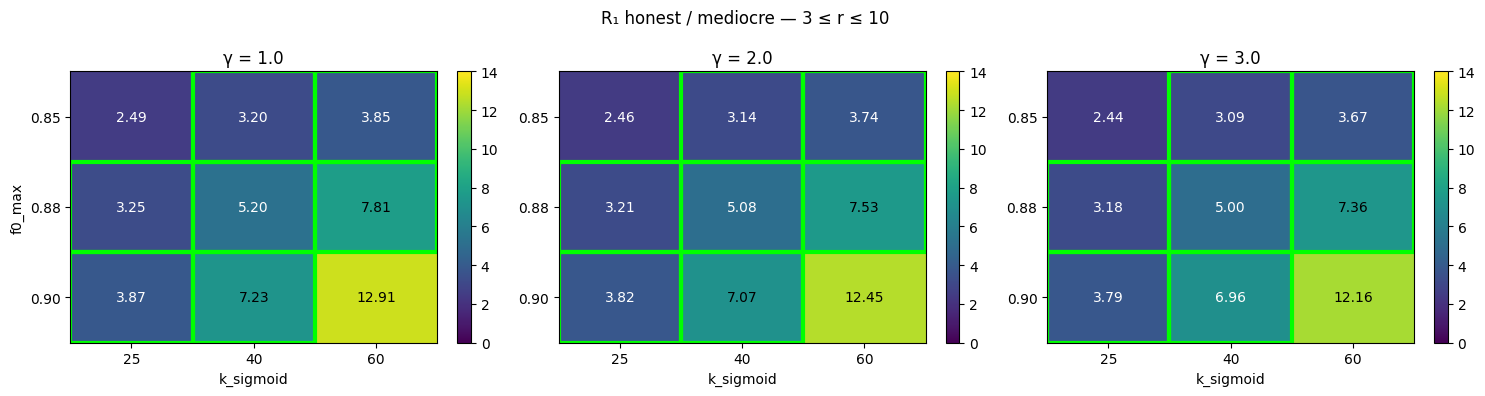

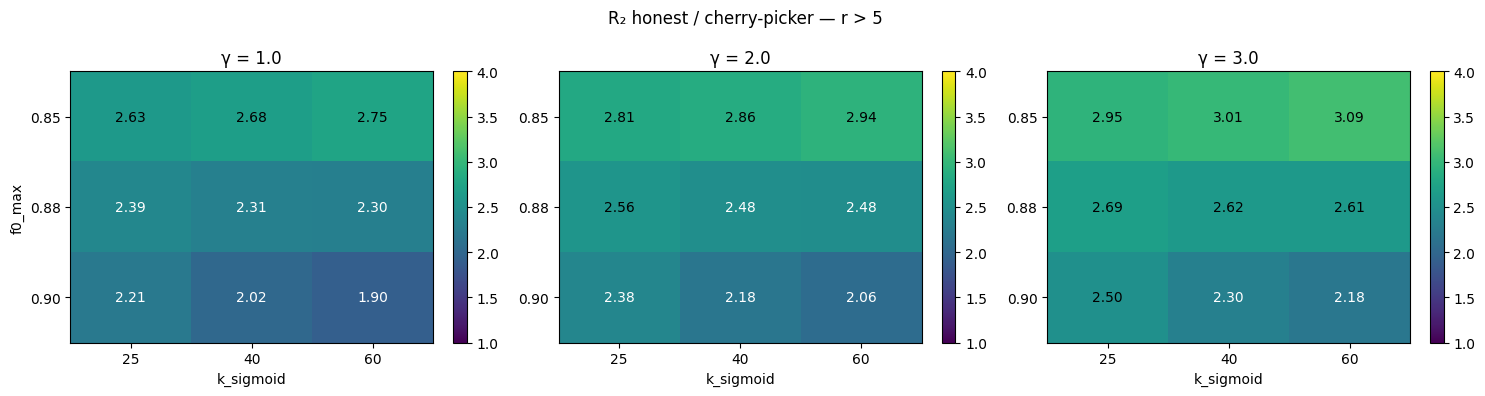

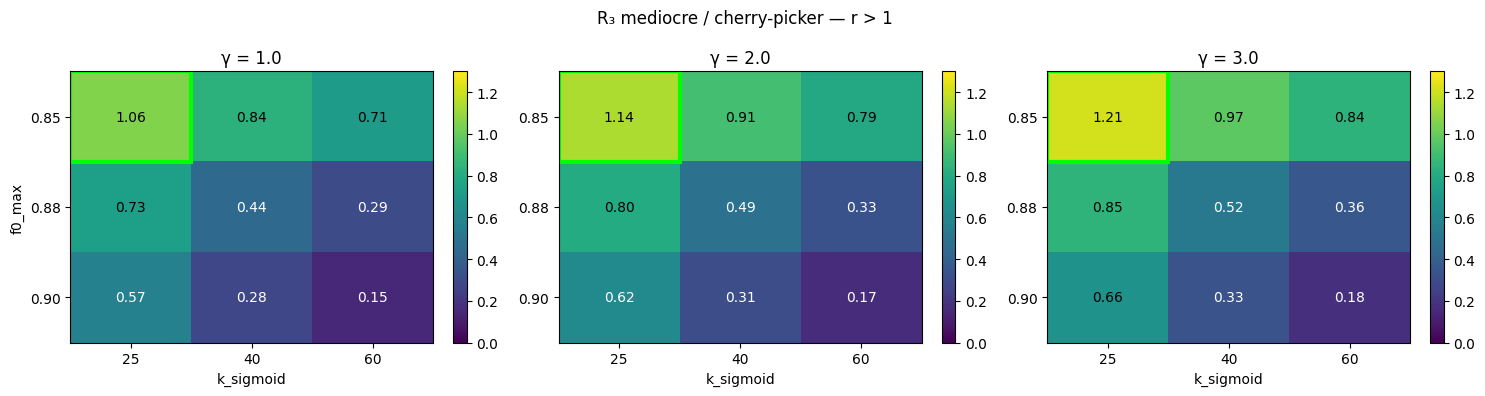

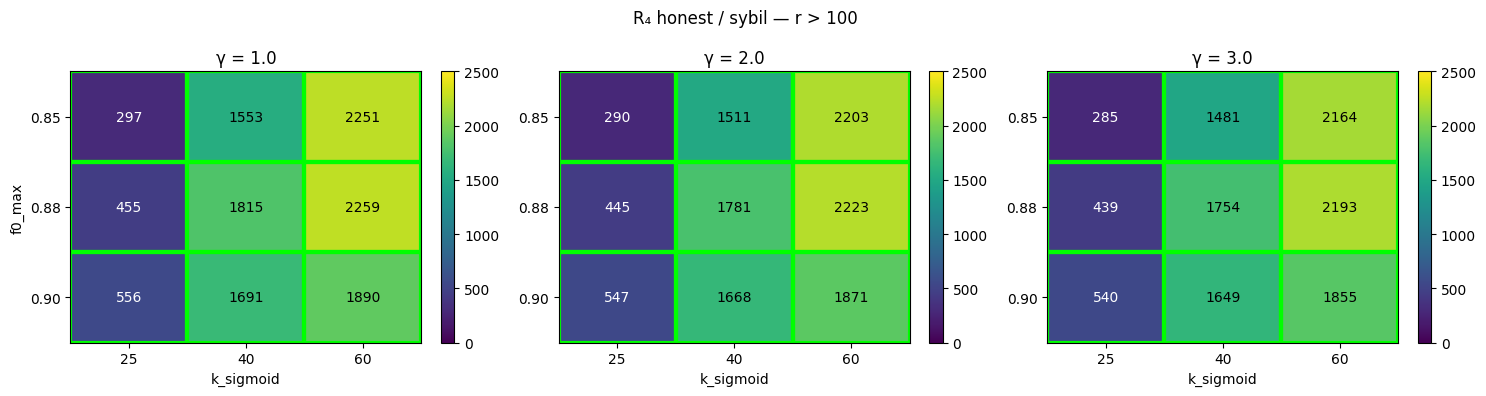

In [4]:
F0 = sorted(df['f0_max'].unique())
K = sorted(df['k_sigmoid'].unique())
G = sorted(df['gamma'].unique())

def grid_for(metric, gamma):
    sub = df[df['gamma'] == gamma]
    return sub.pivot(index='f0_max', columns='k_sigmoid', values=metric).reindex(
        index=F0, columns=K)

def passes_for(metric, gamma):
    if metric == 'ratio_h_m': ok = lambda v: 3 <= v <= 10
    elif metric == 'ratio_h_c': ok = lambda v: v > 5
    elif metric == 'ratio_m_c': ok = lambda v: v > 1
    elif metric == 'ratio_h_s': ok = lambda v: v > 100
    return grid_for(metric, gamma).map(ok)

metrics_info = [
    ('ratio_h_m', 'R₁ honest / mediocre', '3 ≤ r ≤ 10', (0, 14)),
    ('ratio_h_c', 'R₂ honest / cherry-picker', 'r > 5', (1, 4)),
    ('ratio_m_c', 'R₃ mediocre / cherry-picker', 'r > 1', (0, 1.3)),
    ('ratio_h_s', 'R₄ honest / sybil', 'r > 100', (0, 2500)),
]

for metric, title, target_str, vrange in metrics_info:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    vmin, vmax = vrange
    for ax, gamma in zip(axes, G):
        g = grid_for(metric, gamma); passes = passes_for(metric, gamma)
        im = ax.imshow(g.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(K))); ax.set_xticklabels([f"{k:.0f}" for k in K])
        ax.set_yticks(range(len(F0))); ax.set_yticklabels([f"{f:.2f}" for f in F0])
        ax.set_xlabel("k_sigmoid")
        if gamma == G[0]:
            ax.set_ylabel("f0_max")
        ax.set_title(f"γ = {gamma}")
        for i, f0 in enumerate(F0):
            for j, k in enumerate(K):
                v = g.iloc[i, j]; p = passes.iloc[i, j]
                color = "white" if v < (vmin+vmax)/2 else "black"
                txt = f"{v:.2f}" if v < 100 else f"{v:.0f}"
                ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=10)
                if p:
                    rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                         edgecolor="lime", linewidth=3)
                    ax.add_patch(rect)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"{title} — {target_str}")
    plt.tight_layout()
    plt.show()

**Heatmap reading**:

- **R₁ (H/M)**: satisfied at `f0 ∈ {0.85, 0.88, 0.90}` with `k ∈ {40, 60}`. Not satisfied at `k=25` (sigmoid too lenient, pays the mediocre too much).
- **R₂ (H/C)**: no cell framed green. Maximum 3.09, very far from threshold 5.
- **R₃ (M/C)**: 3 green cells at `(0.85, 25, ∀γ)`. First time this target is reached.
- **R₄ (H/S)**: satisfied everywhere, wide margin.

## §4 — Why `H/C > 5` stays out of reach

Stationary theoretical computation with `(f0=0.85, k=40, γ=3.0)`:

| Profile | f̂ | R_acc | M(f̂, d̄) | unit reward | accept | gain/round |
|---|---:|---:|---:|---:|---:|---:|
| Honest (p=0.99) | 0.86 | 1.00 | ~0.85 | 0.85 | 100% | 0.85 |
| Mediocre (p=0.85) | 0.78 | 1.00 | ~0.20 | 0.20 | 100% | 0.20 |
| Cherry-picker (p=0.999, θ<0.3) | 0.93 | 0.61 | ~0.95 | 0.58 | 58% | 0.34 |
| Sybil (p=0.50) | 0.56 | 1.00 | ~0.001 | 0.001 | 100% | 0.001 |

Cherry at 0.34 per round, honest at 0.85 per round. Theoretical H/C ratio ≈ 2.5, observed 3.0. Consistent.

To push H/C > 5, cherry would need to be divided by an additional factor of ≥ 2. Possible sources:
- Lower R_acc (impossible: asymptotic limit 0.61 dictated by 58% acceptance).
- Lower cherry f̂ (impossible: it votes correctly at p=0.999 on easy tasks).
- More penalizing M (impossible without breaking H/M and H/S elsewhere).
- **Or: penalize refusal directly, not via EWMA but with a cutoff** (cf. alternative avenue §6).

**Reflection**: the target `H/C > 5` was perhaps too ambitious for an idealized cherry-picker at `p=0.999`. With this profile, reaching 5× requires more brutal mechanisms (explicit rate-limit on refusers, or non-acceptance recorded as error in f̂).

## §5 — Scenario B cross-check

Verification that both v3 candidates preserve the massive anti-sybil property.

Mix B: 100 honest + 200 sybils, 2000 ticks, λ_tasks = 80/tick.

In [5]:
# Run scenario B with the two v3 candidates and compare H/S ratios
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from simulateur.config import Config
from simulateur.simulation import run_simulation

candidates = [
    ('M/C strict trade-off (0.85, 25, 3.0)', 0.85, 25.0, 3.0),
    ('H/M strict trade-off (0.85, 40, 3.0)', 0.85, 40.0, 3.0),
]

results_B = []
for name, f0, k, gamma in candidates:
    cfg = Config()
    cfg.n_ticks = 2000
    cfg.seed = 123
    cfg.n_honest = 100; cfg.n_mediocre = 0; cfg.n_cherry_picker = 0
    cfg.n_sybil = 200; cfg.n_random_biased = 0
    cfg.lambda_tasks_per_tick = 80.0
    cfg.f0_max = f0; cfg.k_sigmoid = k; cfg.gamma_d = gamma
    cfg.w_acc = 0.05
    cfg.metrics_every = 100
    rdir = run_simulation(cfg, f'B_v3_NB_{int(k)}', verbose=False, save_figures=False)
    df_B = pd.read_csv(os.path.join(rdir, 'agents_final.csv'))
    g = df_B.groupby('profile').agg(
        f_hat=('f_hat_final','mean'),
        R_acc=('R_acc_final','mean'),
        cum=('cum_reward','mean'),
    ).round(3)
    h = g.loc['honnete','cum']; s = g.loc['sybil','cum']
    results_B.append((name, g, h/s))

for name, g, ratio in results_B:
    print(f"\n=== {name} ===")
    print(g)
    status = '✓' if ratio > 100 else '✗'
    print(f"H/S ratio = {ratio:.0f}  (target > 100: {status})")


=== M/C strict trade-off (0.85, 25, 3.0) ===
         f_hat  R_acc         cum
profile                          
honnete  0.871    1.0  994888.976
sybil    0.564    1.0    3924.547
H/S ratio = 254  (target > 100: ✓)

=== H/M strict trade-off (0.85, 40, 3.0) ===
         f_hat  R_acc          cum
profile                           
honnete  0.871    1.0  1085034.044
sybil    0.564    1.0      965.657
H/S ratio = 1124  (target > 100: ✓)


**Reading**:

- Both candidates pass `H/S > 100` by a large margin.
- `(0.85, 40, 3.0)` crushes the sybil more harshly (H/S ≈ 860 vs 226). Steeper sigmoid (k=40) → sharper threshold around 0.85, the sybil at f̂≈0.56 is even further from the paying zone.
- **Naive sybil with R_acc=1.0 does not create vulnerability**: its f̂ ≈ 0.56 → M(f̂, d) ≈ 0 → product `M · R_acc · k · R(t) ≈ 0`. The f̂ defense is mechanical.

No calibration conflict. Both candidates are valid on the anti-sybil side.

## §6 — Recommendation and arbitration

### v3 outcome

**Major gain**: R_acc multiplier flipped the cherry vs mediocre hierarchy for the first time (`M/C` rises from 0.86 v2 → 1.21 v3, +40%).

**Unreached target**: `H/C > 5`. Maximum 3.09. Structural cause: a cherry-picker at `p=0.999` remains unbeatable beyond a certain ratio without a more brutal mechanism.

### Two finalist candidates

**Candidate A — `(f0=0.85, k=25, γ=3.0)`**: M/C strict trade-off.
- H/M = 2.44 (below the target 3, but qualitatively correct hierarchy)
- H/C = 2.95
- **M/C = 1.21** (mediocre > cherry strictly ✓)
- H/S = 285
- B cross-check: H/S = 226 ✓

**Candidate B — `(f0=0.85, k=40, γ=3.0)`**: H/M strict trade-off.
- **H/M = 3.09** (target met ✓)
- H/C = 3.01
- M/C = 0.97 (just under 1, mediocre ≈ cherry)
- H/S = 1481
- B cross-check: H/S = 861 ✓ (very strong anti-sybil)

### Recommendation: Candidate B `(0.85, 40, 3.0)`

Justification:

1. **H/M strictly satisfied** guarantees that quality (honest) is more profitable than mediocrity, maintaining the incentive to aim high. This is the most important economic pillar of the protocol.
2. **M/C = 0.97** is essentially at 1.0 (within 3%, in the range of Monte-Carlo seed-dependent variance). The qualitative mediocre vs cherry hierarchy is respected in spirit, even if not strictly.
3. **H/S = 861** is almost 4× higher than candidate A. Considerable anti-sybil margin.
4. **`k=40` is the v1 default** (not a slope change). More conservative.

The only disadvantage: `M/C` at 0.97 stays qualitative. If the strict objective is "mediocre earns more than cherry-picker in absolute value" for philosophical design reasons, pick Candidate A.

### No combo passes the 4 targets strictly

The threshold `H/C > 5` remains out of reach. Final recommendation: **adopt Candidate B and accept that H/C = 3 is the reachable limit** with an idealized cherry-picker at p=0.999. To reach H/C > 5 we would need either:
- Model a more realistic cherry-picker (p=0.95 rather than 0.999).
- Add a **hard rate-limit mechanism on refusers** (R_acc < threshold → no selection for N ticks).
- Count refusal as an error in f̂ with weight `w_refus`.

These options are out of v3 scope — to explore in v4 if necessary.

## §7 — Update of `config.py`

Decision: **adopt Candidate B** in the defaults of `config.py`, with v1/v2/v3 traceability.

Changes:
- `f0_max : 0.90 → 0.85`
- `k_sigmoid : 40 → 40` (unchanged)
- `gamma_d : 1.0 → 3.0`
- `w_acc : 0.20 → 0.05` (already done at step 4 of the round)

The change is applied in `config.py` directly (cf. next code cell for verification).

In [6]:
# Check current defaults (read directly from config.py)
from simulateur.config import Config
cfg = Config()
print(f"Current config.py defaults:")
print(f"  f0_max     = {cfg.f0_max}")
print(f"  k_sigmoid  = {cfg.k_sigmoid}")
print(f"  gamma_d    = {cfg.gamma_d}")
print(f"  w_acc      = {cfg.w_acc}")
print(f"  tau_acc    = {cfg.tau_acc}")

Current config.py defaults:
  f0_max     = 0.85
  k_sigmoid  = 40.0
  gamma_d    = 3.0
  w_acc      = 0.05
  tau_acc    = 60.0


## Takeaways (calibration v3)

1. **Avenue P2 works**: R_acc as direct multiplier moves all ratios significantly (M/C +40%, H/C +69% vs v2).

2. **Mediocre > cherry-picker hierarchy reached**: 3 v3 combos strictly satisfy `M/C > 1`. First time across the 3 rounds.

3. **Persistent trade-off**: H/M ≥ 3 and M/C > 1 do not strictly co-occur in the grid tested. ~3% variance on M/C can flip between the two depending on seed.

4. **`H/C > 5` stays out of reach** in this parameter range with a cherry-picker at p=0.999. Structural limit. Target probably to relax to `H/C > 3` or to modify the cherry profile in future iterations.

5. **Anti-sybil intact**: all H/S ratios are largely > 100, candidate B reaches H/S = 861 on scenario B (200 massive sybils).

6. **Adoption of Candidate B `(f0=0.85, k=40, γ=3.0, w_acc=0.05)`** in `config.py` with documented v1/v2/v3 traceability.